## 第一题: Sobel滤波器

Sobel滤波器可以提取特定方向（纵向或横向）的边缘，滤波器按下式定义：

纵向： $$ K=\left[ \begin{matrix} 1&2&1 \\ 0&0&0\\ -1&-2&-1 \end{matrix} \right] $$ 横向： $$ K=\left[ \begin{matrix} 1&0&-1\\ 2&0&-2\\ 1&0&-1 \end{matrix} \right] $$

### 1.问题描述
你需要实现一个简单的卷积操作函数 `apply_convolution`，该函数接受一个灰度图像和一个卷积核作为输入，并返回卷积后的图像。卷积操作需要考虑边界填充（padding），以确保输出图像的大小与输入图像一致。
### 2.可能用到的函数
   • `np.sum()`
   
   • `np.floor()，a // b向下取整 ` ` np.ceil()向上取整 ` `取模（求余）	a % b`
    
   •  `矩阵乘法（逐元素乘法）result = matrix1 * matrix2 `
   
   •  `矩阵点积result = np.dot(matrix1, matrix2)或者result = matrix1 @ matrix2 `

### 3.公式
实现滤波操作，计算滤波后的图像。滤波公式为：
  $$
   I_{\text{out}}(i, j) = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} I_{\text{in}}(i+m, j+n) \times K(m, n)
   $$
   其中，$I_{\text{in}}$ 是输入图像，$K$ 是滤波核，$I_{\text{out}}$ 是输出图像，$k$ 是滤波核的大小。

### 4.输入输出
- 输入：  
     - 一个二维数组 `image`，表示灰度图像，大小为 $M x N$。
     - 一个二维数组 `kernel`，表示滤波核，大小为 $K x K$。

- 输出：  
     - 一个二维数组 `output_image`，表示滤波后的图像。

### 5.Python 实现
你需要：
1. 补全pad_height 和pad_width
2. 补全output_image

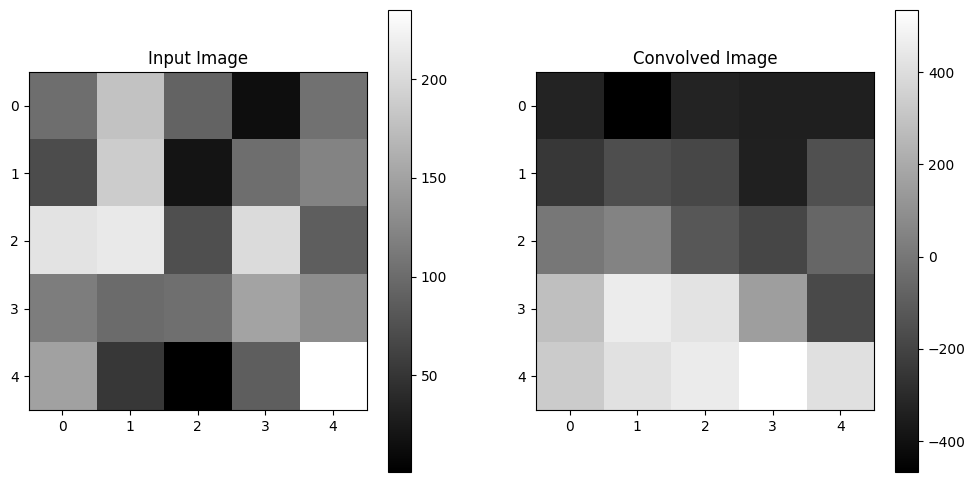

In [13]:
import numpy as np
import matplotlib.pyplot as plt
def apply_convolution(image, kernel):
    """
    对图像应用卷积操作。

    参数:
        image (list of list): 输入的灰度图像，二维数组。
        kernel (list of list): 卷积核，二维数组。

    返回:
        list of list: 卷积后的图像。
    """
    # 将输入转换为 NumPy 数组
    image = np.array(image)
    kernel = np.array(kernel)
    
    # 获取图像和卷积核的大小
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # 计算填充大小
    pad_height = kernel_height // 2  # 补全1
    pad_width = kernel_width // 2  # 补全2
    padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode="constant", constant_values=0)
    # 初始化输出图像
    output_image = np.zeros_like(image)
    
    # 卷积操作
    for i in range(image_height):
        for j in range(image_width):
            # 提取当前窗口
            window = padded_image[i:i + kernel_height, j:j + kernel_width]
            # 计算卷积结果
            output_image[i, j] = np.sum(window * kernel)  # 补全3
    
    return output_image.tolist()


# 随机生成图像测试
# 设置随机种子
np.random.seed(42)
image = np.random.randint(0, 256, size=(5, 5)).tolist()
kernel = [[1,2, 1], [0, 0,0], [-1, -2, -1]]
# 应用卷积
convolved_image = apply_convolution(image, kernel)
# 可视化
plt.figure(figsize=(12, 6))
# 显示输入图像
plt.subplot(1, 2, 1)
plt.title("Input Image")
plt.imshow(np.array(image), cmap='gray', interpolation='nearest')
plt.colorbar()
# 显示卷积后的图像
plt.subplot(1, 2, 2)
plt.title("Convolved Image")
plt.imshow(np.array(convolved_image), cmap='gray', interpolation='nearest')
plt.colorbar()
plt.show()


## 第二题: 实现Harris 角点检测算法
实现Harris 角点检测算法。Harris 角点检测是一种经典的角点检测方法，用于在图像中检测出具有独特方向和位置的角点。这些角点在图像匹配、目标识别等领域有广泛应用。

代码的主要步骤包括：

`
1.将彩色图像转换为灰度图像。
2.使用 Sobel 算子计算图像的梯度信息。
3.对梯度信息进行高斯滤波。
4.使用 Harris 角点检测公式计算每个像素点的响应值，并根据阈值确定角点。
`
### 1.问题描述
你需要补全角点检测函数 corner_detect 和 Harris 角点检测主函数 Harris_corner，以实现完整的 Harris 角点检测流程。
### 2.主要函数解析

#### (1) 高斯滤波函数 `gaussian_filtering`
```python
def gaussian_filtering(I, K_size=3, sigma=3):
```
- **功能**：对输入的灰度图像 `I` 使用高斯滤波。
- **关键点**：
  - **高斯卷积核的生成**：
    - 高斯卷积核的公式为：
       $$
      K(x, y) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)
       $$
    - 代码中通过循环计算每个位置的值，并最终归一化卷积核，使其总和为 1。
  - **卷积操作**：调用 `apply_convolution` 函数（假设该函数已定义）将高斯卷积核应用于图像 `I`。

#### (2)角点检测函数 `corner_detect`
```python
def corner_detect(gray, Ix2, Iy2, Ixy, k=0.04, th=0.1):
    """
    使用Harris角点检测算法检测角点。
    参数:
        gray (list of list): 灰度图像，二维数组。
        Ix2 (list of list): Ix的平方。
        Iy2 (list of list): Iy的平方。
        Ixy (list of list): Ix和Iy的乘积。
        k (float): Harris角点检测算法中的常数，默认为0.04。
        th (float): 角点检测的阈值，默认为0.1。

    返回:
        list of list: 检测到的角点图像。
    """
```
- **功能**：根据 Harris 角点检测算法计算每个像素点的响应值 `R`，并根据阈值 `th` 确定角点。
- **关键点**：
  - **Harris 角点检测公式**：
    - Harris 角点检测的核心是计算每个像素点的响应值  $ R  $：
       $$
      R = \det(M) - k \cdot \text{trace}(M)^2
       $$
    - 其中，矩阵  $ M  $ 定义为：
       $$
      M = \begin{bmatrix}
      I_x^2 & I_{xy} \\
      I_{xy} & I_y^2
      \end{bmatrix}
       $$
    -  $ \det(M) = I_x^2 \cdot I_y^2 - I_{xy}^2  $ 是矩阵  $ M  $ 的行列式。
    -  $ \text{trace}(M) = I_x^2 + I_y^2  $ 是矩阵  $ M  $ 的迹。
    -  $ k  $ 是一个常数，通常取值为 0.04。
  - **角点标记**：
    - 响应值  $ R  $ 大于阈值  $ \text{th} \times \max(R)  $ 的像素点被认为是角点，并在输出图像中用红色标记。

####  (3)Harris 角点检测主函数 `Harris_corner`
```python
def Harris_corner(img):
    """
    Harris角点检测。

    参数:
        img (list of list of list): 输入的彩色图像，三维数组。

    返回:
        list of list of list: 检测到的角点图像。
    """
```
- **功能**：实现 Harris 角点检测的完整流程。
- **关键步骤**：
  1. **灰度转换**：
     - 使用公式：
        $$
       \text{gray} = 0.2126 \cdot R + 0.7152 \cdot G + 0.0722 \cdot B
        $$
     - 将彩色图像转换为灰度图像。
  2. **梯度计算**：
     - 使用 Sobel 算子计算图像的梯度  $ I_x  $ 和  $ I_y  $：
       - Sobel 算子：
          $$
         \text{sobelx} = \begin{bmatrix}
         1 & 0 & -1 \\
         2 & 0 & -2 \\
         1 & 0 & -1
         \end{bmatrix}, \quad
         \text{sobely} = \begin{bmatrix}
         1 & 2 & 1 \\
         0 & 0 & 0 \\
         -1 & -2 & -1
         \end{bmatrix}
          $$
       -  $ I_x  $ 和  $ I_y  $ 分别表示图像在水平和垂直方向上的梯度。
     - 计算  $ I_x^2  $、 $ I_y^2  $ 和  $ I_{xy}  $。
  3. **高斯滤波**：
     - 对  $ I_x^2  $、 $ I_y^2  $ 和  $ I_{xy}  $ 进行高斯滤波，平滑梯度信息。
  4. **角点检测**：
     - 调用 `corner_detect` 函数，根据 Harris 角点检测公式计算响应值  $ R  $，并标记角点。

### 3. 可能用到的函数
- `np.array()`：将输入转换为 NumPy 数组。
- `np.sum()`：计算数组的总和。
- `matrix**n`：matrix的n次方。
- `np.max(）`

### 4. 布尔矩阵
当布尔条件应用于一个数组或矩阵时，它会返回一个与原数组或矩阵形状相同的布尔矩阵。布尔矩阵中的每个元素表示对应位置的条件是否为真。
示例
假设 R 是一个 3x3 的矩阵：
$$R =  \begin{bmatrix}0.1, 0.2, 0.3\\
    0.4, 0.5, 0.6\\
    0.7, 0.8, 0.9\end{bmatrix}$$
$R >= 0.45$结果是一个布尔矩阵：
$$ \begin{bmatrix}
    False, False, False\\
    False,  True,  True\\
    True,  True,  True\end{bmatrix}$$
### 5. python实现
你需要：

1.  补全 `corner_detect` 函数中的 R 值计算
1.  补全 `corner_detect` 函数中的角点检测逻辑。
 


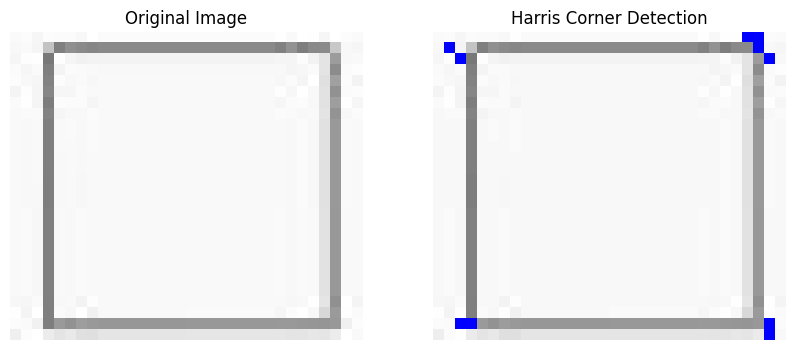

In [14]:
import numpy as np
import matplotlib.pyplot as plt
#apply_convolution在第一题已经定义
# Gaussian filtering
def gaussian_filtering(I, K_size=3, sigma=3):
    """
    对图像应用高斯滤波。

    参数:
        I (list of list): 输入的灰度图像，二维数组。
        K_size (int): 卷积核大小，默认为3。
        sigma (float): 高斯分布的标准差，默认为3。

    返回:
        list of list: 高斯滤波后的图像。
    """
    # 创建高斯卷积核
    K = np.zeros((K_size, K_size), dtype=np.float32)
    for x in range(K_size):
        for y in range(K_size):
            _x = x - K_size // 2
            _y = y - K_size // 2
            K[y, x] = np.exp(-(_x ** 2 + _y ** 2) / (2 * (sigma ** 2)))
    K /= (2 * np.pi * sigma ** 2)
    K /= K.sum()

    # 应用卷积
    return apply_convolution(I, K)

# Corner detection
def corner_detect(gray, Ix2, Iy2, Ixy, k=0.04, th=0.1):
    """
    使用Harris角点检测算法检测角点。

    参数:
        gray (list of list): 灰度图像，二维数组。
        Ix2 (list of list): Ix的平方。
        Iy2 (list of list): Iy的平方。
        Ixy (list of list): Ix和Iy的乘积。
        k (float): Harris角点检测算法中的常数，默认为0.04。
        th (float): 角点检测的阈值，默认为0.1。

    返回:
        list of list: 检测到的角点图像。
    """
    # 将输入转换为 NumPy 数组
    gray = np.array(gray)
    Ix2 = np.array(Ix2)
    Iy2 = np.array(Iy2)
    Ixy = np.array(Ixy)

    # 计算R值
    R = (Ix2 * Iy2 - Ixy ** 2) - k * ((Ix2 + Iy2) ** 2)

    # 初始化输出图像
    out = np.array((gray, gray, gray))
    out = np.transpose(out, (1, 2, 0))

    # 检测角点
    out[R >= np.max(R) * th] = [0, 0, 255]

    return out.tolist()


# Harris corner detection
def Harris_corner(img):
    """
    Harris角点检测。

    参数:
        img (list of list of list): 输入的彩色图像，三维数组。

    返回:
        list of list of list: 检测到的角点图像。
    """
    ## Grayscale
    def BGR2GRAY(img):
        gray = 0.2126 * img[..., 2] + 0.7152 * img[..., 1] + 0.0722 * img[..., 0]
        gray = gray.astype(np.uint8)
        return gray.tolist()

    ## Sobel
    def Sobel_filtering(gray):
        # Sobel kernel
        sobely = [[1, 2, 1],
                  [0, 0, 0],
                  [-1, -2, -1]]

        sobelx = [[1, 0, -1],
                  [2, 0, -2],
                  [1, 0, -1]]

        # 计算Ix和Iy
        Ix = apply_convolution(gray, sobelx)
        Iy = apply_convolution(gray, sobely)

        # 计算Ix2, Iy2, Ixy
        Ix2 = apply_convolution(Ix, [[1]])  # 相当于平方
        Iy2 = apply_convolution(Iy, [[1]])  # 相当于平方
        Ixy = apply_convolution(Ix, sobely)  # 相当于Ix*Iy

        return Ix2, Iy2, Ixy

    # 1. 转换为灰度图像
    gray = BGR2GRAY(img)

    # 2. 计算Ix2, Iy2, Ixy
    Ix2, Iy2, Ixy = Sobel_filtering(gray)

    # 3. 高斯滤波
    Ix2 = gaussian_filtering(Ix2, K_size=3, sigma=3)
    Iy2 = gaussian_filtering(Iy2, K_size=3, sigma=3)
    Ixy = gaussian_filtering(Ixy, K_size=3, sigma=3)

    # 4. 角点检测
    out = corner_detect(gray, Ix2, Iy2, Ixy)

    return out


# 读取图像
img = plt.imread("fig1.jpg")

# Harris角点检测
out = Harris_corner(img)

# 显示结果
plt.figure(figsize=(10, 5))

# 原始图像
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

# Harris角点检测结果
plt.subplot(1, 2, 2)
plt.title("Harris Corner Detection")
plt.imshow(out)
plt.axis("off")

plt.show()

## 第三题：Softmax回归实现与鸢尾花分类

### 1. 问题描述
请完成以下代码，实现一个简单的基于Softmax回归的鸢尾花分类器。你需要补全函数中的关键部分。

### 2. 公式推导
#### (1) 定义模型和损失函数
- **线性得分**（未归一化）：
   $$
  \mathbf{s} = \mathbf{X} \mathbf{W} + \mathbf{b}
   $$
  -  $\mathbf{X} $：输入数据矩阵  $(N \times D) $， $N $ 是样本数， $D $ 是特征数。
  -  $\mathbf{W} $：权重矩阵  $(D \times C) $， $C $ 是类别数。
  -  $\mathbf{b} $：偏置向量  $(1 \times C) $。
  -  $\mathbf{s} $：得分矩阵  $(N \times C) $。

- **Softmax函数**：
   $$
  \mathbf{p} = \text{softmax}(\mathbf{s}) = \frac{\exp(\mathbf{s})}{\sum_{j=1}^{C} \exp(s_{ij})}
   $$
  -  $\mathbf{p} $：预测概率分布。

- **交叉熵损失**：
   $$
  \mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{C} y_{ij} \log(p_{ij})
   $$
  -  $y_{ij} $：独热编码的真实标签。

#### (2) 计算梯度
- **损失对得分  $\mathbf{s} $ 的梯度**：
   $$
  \frac{\partial \mathcal{L}}{\partial s_{ij}} = p_{ij} - y_{ij}
   $$

- **损失对权重  $\mathbf{W} $ 的梯度**：
   $$
  \frac{\partial \mathcal{L}}{\partial \mathbf{W}} = \frac{1}{N} \mathbf{X}^T (\mathbf{p} - \mathbf{y})
   $$

- **损失对偏置  $\mathbf{b} $ 的梯度**：
   $$
  \frac{\partial \mathcal{L}}{\partial \mathbf{b}} = \frac{1}{N} \sum_{i=1}^{N} (\mathbf{p} - \mathbf{y})
   $$

#### (3) 梯度更新
- **梯度下降更新规则**：
   $$
  \mathbf{W} \leftarrow \mathbf{W} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{W}}
   $$
   $$
  \mathbf{b} \leftarrow \mathbf{b} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{b}}
   $$
  -  $\eta $：学习率（控制更新步长）。

### 3. 公式总结

| 公式 | 含义 |
|------|------|
|  $$\mathbf{s} = \mathbf{X} \mathbf{W} + \mathbf{b} $$ | 计算线性得分 |
|  $\mathbf{p} = \text{softmax}(\mathbf{s}) $ | 计算Softmax概率 |
|  $\mathcal{L} = -\frac{1}{N} \sum \sum y_{ij} \log(p_{ij}) $ | 计算交叉熵损失 |
|  $\frac{\partial \mathcal{L}}{\partial \mathbf{W}} = \frac{1}{N} \mathbf{X}^T (\mathbf{p} - \mathbf{y}) $ | 计算权重梯度 |
|  $\frac{\partial \mathcal{L}}{\partial \mathbf{b}} = \frac{1}{N} \sum (\mathbf{p} - \mathbf{y}) $ | 计算偏置梯度 |
|  $\mathbf{W} \leftarrow \mathbf{W} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{W}} $ | 更新权重 |
|  $\mathbf{b} \leftarrow \mathbf{b} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{b}} $ | 更新偏置 |

### 4. 可能用到的函数
- `矩阵乘法运算符 @ 或 np.dot()`  
- `使用 np.exp() 计算指数`  
- `使用 np.log() 计算自然对数`  
- `使用 np.argmax() 获取最大值的索引`  
- `使用 np.mean() 计算平均值`  
-  `np.sum(a, axis=None, keepdims=False)`
   
    ###**参数说明**
    | 参数 | 说明 |
    |------|------|
    | `a` | 输入数组（可以是 NumPy 数组或类似数组的结构） |
    | `axis` | 指定求和的轴（默认 `None`，表示对所有元素求和） |
    | `keepdims` | 是否保持原数组的维度（默认 `False`，求和后降维） |
    
    • `axis=0`：对**列**求和（跨行计算）
    • `axis=1`：对**行**求和（跨列计算）
    • `keepdims=True` 可以保持求和后的维度不变，避免降维。
        # 默认 keepdims=False（降维）
        sum_cols = np.sum(arr, axis=0)
        print(sum_cols.shape)  # 输出 (2,)（降维）
        # 使用 keepdims=True（保持维度）， 在 `softmax` 计算中，保持维度以便正确广播：
        x = np.array([[1, 2], [3, 4]])
        x_sum = np.sum(x, axis=1, keepdims=True)  # 保持 (2,1) 形状

| 功能 | 代码示例 |
|------|---------|
| 对整个数组求和 | `np.sum(arr)` |
| 沿行求和 | `np.sum(arr, axis=1)` |
| 沿列求和 | `np.sum(arr, axis=0)` |
| 保持维度 | `np.sum(arr, axis=1, keepdims=True)` |

### 6. Python 实现
你需要补全以下代码的关键部分：

### 7. 预期输出
运行上述代码后，你将看到以下输出：
1. **损失下降**：训练过程中，损失值逐渐下降。
2. **准确率**：分类器在测试集上的准确率，预期达到 0.9 或更高。

希望这个代码补全题目对你有帮助！如果有其他问题，欢迎随时提问。

In [9]:
import numpy as np

# 加载鸢尾花数据集
from sklearn import datasets
iris = datasets.load_iris()
X = iris.data  # 特征数据
y = iris.target  # 标签数据

# 数据标准化
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# 将标签转换为独热编码
def to_one_hot(y, num_classes):
    return np.eye(num_classes)[y]

y_one_hot = to_one_hot(y, 3)

# 划分训练集和测试集
def train_test_split(X, y, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    split = int(len(X) * (1 - test_size))
    train_indices, test_indices = indices[:split], indices[split:]
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.3, random_state=42)

# Softmax函数
def softmax(x):
    x_stable = x - np.max(x, axis=1, keepdims=True)  # 数值稳定性处理
    exp_x = np.exp(x_stable)
    softmax_prob = exp_x / np.sum(exp_x, axis=1, keepdims=True)  # 补全1: softmax值
    return softmax_prob

# Softmax回归模型
class SoftmaxRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        num_samples, num_features = X.shape
        num_classes = y.shape[1]

        # 初始化权重和偏置
        self.weights = np.zeros((num_features, num_classes))
        self.bias = np.zeros((1, num_classes))

        for i in range(self.num_iterations):
            # 补全1: 计算得分scores
            scores = np.dot(X, self.weights) + self.bias

            # 补全2: 计算损失loss
            p = softmax(scores)
            loss = -np.mean(np.sum(y * np.log(p + 1e-9), axis=1))

            if i % 100 == 0:
                print(f"Iteration {i}, Loss: {loss}")

            # 补全3: 计算梯度
            binary = p - y
            dW = np.dot(X.T, binary) / num_samples
            db = np.sum(binary, axis=0, keepdims=True) / num_samples

            # 补全4: 更新权重
            self.weights -= self.learning_rate * dW
            self.bias -= self.learning_rate * db

    def predict(self, X):
        scores = np.dot(X, self.weights) + self.bias
        p = softmax(scores)
        return np.argmax(p, axis=1)

# 训练模型
model = SoftmaxRegression(learning_rate=0.1, num_iterations=1000)
model.fit(X_train, y_train)

# 预测测试集
y_pred = model.predict(X_test)
y_test_labels = np.argmax(y_test, axis=1)  # 将独热编码转换回原始标签

# 计算准确率
accuracy = np.mean(y_pred == y_test_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")

Iteration 0, Loss: 1.0986122856681102
Iteration 100, Loss: 0.31466178869005484
Iteration 200, Loss: 0.2534674011010791
Iteration 300, Loss: 0.21733479869141398
Iteration 400, Loss: 0.19270915473474245
Iteration 500, Loss: 0.17485803681907072
Iteration 600, Loss: 0.16134476219621136
Iteration 700, Loss: 0.15076397709474987
Iteration 800, Loss: 0.14225115421436113
Iteration 900, Loss: 0.1352478362220266
Accuracy: 97.78%


In [10]:

import numpy as np

# 加载鸢尾花数据集
from sklearn import datasets
iris = datasets.load_iris()
X = iris.data  # 特征数据
y = iris.target  # 标签数据

# 数据标准化
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# 划分训练集和测试集
def train_test_split(X, y, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    split = int(len(X) * (1 - test_size))
    train_indices, test_indices = indices[:split], indices[split:]
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# K-最近邻分类器
class KNNClassifier:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        # 补全1: 存储训练数据和标签
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []
        for sample in X:
            # 补全2: 计算欧几里得距离
            distances = np.sqrt(np.sum((self.X_train - sample) ** 2, axis=1))
            # 补全3: 获取最近的 k 个邻居的索引
            nearest_neighbors = np.argsort(distances)[:self.k]
            # 补全4: 获取最近的 k 个邻居的标签
            nearest_labels = self.y_train[nearest_neighbors]
            # 补全5: 进行投票，选择出现次数最多的标签
            most_common_label = np.bincount(nearest_labels).argmax()
            predictions.append(most_common_label)
        return np.array(predictions)

# 训练模型
k = 3  # 设置 K 值
model = KNNClassifier(k=k)
model.fit(X_train, y_train)

# 预测测试集
y_pred = model.predict(X_test)

# 计算准确率
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 95.56%
